# CNN-RNN Model for EEG-Based Emotion Recognition
## Based on R. K. Sharma et al.
### Architecture: TimeDistributed CNN followed by recurrent (LSTM) layers
### Dataset: DEAP (preprocessed)

---

This notebook implements the **CNN-RNN** model described by **R. K. Sharma et al.** in their paper *"An XAI-Based CNN-RNN Model for Emotion Recognition with Multi-Channel Signals"*.

The architecture uses:
- **TimeDistributed Conv1D** layers to learn spatial-temporal EEG features inside each 2-second segment
- **Stacked LSTM** layers to capture temporal dependencies across the ordered segment embeddings
- **Dense classification head** with sigmoid activation for binary valence classification
- **SHAP (SHapley Additive exPlanations)** values to quantify raw feature, EEG-channel, and temporal-segment contributions


In [1]:
import os
import pickle
import gc
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from scipy.signal import butter, filtfilt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))


2026-05-13 23:53:20.357546: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778716400.852717      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778716400.961743      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778716402.094434      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778716402.094470      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778716402.094472      57 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 1. Configuration and Hyperparameters

In [2]:
# Data parameters
LOCAL_DATA_DIR = r"C:\Users\abdelrahman elsayed\Desktop\XAI Models\data_preprocessed_python"
DATA_DIR_CANDIDATES = [
    os.environ.get("DEAP_DATA_DIR"),
    LOCAL_DATA_DIR,
    "/kaggle/input/datasets/manh123df/deap-dataset/deap-dataset/data_preprocessed_python",
    "/kaggle/input/deap-dataset/deap-dataset/data_preprocessed_python",
    "/kaggle/input/deap-dataset/data_preprocessed_python",
    os.path.join(os.getcwd(), "data_preprocessed_python"),
]

def find_deap_data_dir():
    for candidate in DATA_DIR_CANDIDATES:
        if candidate and os.path.isdir(candidate):
            return candidate

    for search_root in ("/kaggle/input", "/content"):
        if not os.path.isdir(search_root):
            continue
        for current_dir, _, filenames in os.walk(search_root):
            if os.path.basename(current_dir) == "data_preprocessed_python":
                return current_dir
            if {"s01.dat", "s02.dat", "s03.dat"}.issubset(filenames):
                return current_dir

    return os.environ.get("DEAP_DATA_DIR") or LOCAL_DATA_DIR

DATA_DIR = find_deap_data_dir()
FS = 128                   # Sampling frequency (Hz)
LOWCUT = 4.0               # Bandpass filter low cutoff (Hz)
HIGHCUT = 45.0             # Bandpass filter high cutoff (Hz)
BASELINE_SEC = 3           # Baseline period (seconds)
N_CHANNELS = 32            # Number of EEG channels
EEG_CHANNEL_NAMES = [
    "Fp1", "AF3", "F3", "F7", "FC5", "FC1", "C3", "T7",
    "CP5", "CP1", "P3", "P7", "PO3", "O1", "Oz", "Pz",
    "Fp2", "AF4", "Fz", "F4", "F8", "FC6", "FC2", "Cz",
    "C4", "T8", "CP6", "CP2", "P4", "P8", "PO4", "O2",
]
BASELINE_SAMPLES = BASELINE_SEC * FS  # 384 samples
VALID_SUBJECTS = [i for i in range(1, 33) if i != 4]  # Subject 4 intentionally excluded
REQUIRED_DATA_FILES = [f"s{i:02d}.dat" for i in VALID_SUBJECTS]

# Segmentation parameters
SEGMENT_LENGTH_SEC = 2     # Each segment is 2 seconds
SEGMENT_LENGTH = SEGMENT_LENGTH_SEC * FS  # 256 samples per segment

# Model hyperparameters (Sharma et al. CNN-RNN)
CNN_FILTERS_1 = 64         # Filters in 1st Conv1D layer
CNN_FILTERS_2 = 128        # Filters in 2nd Conv1D layer
CNN_KERNEL_SIZE = 5        # Kernel size for Conv1D
POOL_SIZE = 2              # MaxPooling size
LSTM_UNITS_1 = 128         # Units in 1st LSTM layer
LSTM_UNITS_2 = 64          # Units in 2nd LSTM layer
DENSE_UNITS = 64           # Units in the dense layer
DROPOUT_RATE = 0.3         # Dropout fraction
LEARNING_RATE = 0.001      # Adam learning rate
BATCH_SIZE = 32            # Training batch size
EPOCHS = 30                # Number of training epochs

# SHAP parameters (keep these modest; SHAP over sequence models is compute-heavy)
SHAP_BACKGROUND_SIZE = 64  # Training examples used as the SHAP reference distribution
SHAP_EXPLAIN_SIZE = 32     # Test examples explained globally
SHAP_NSAMPLES = 100        # GradientExplainer Monte Carlo samples when fallback is used
SHAP_RANDOM_STATE = 42


In [3]:
# Preflight DEAP dataset validation
if not os.path.isdir(DATA_DIR):
    checked_dirs = "\n  ".join(candidate for candidate in DATA_DIR_CANDIDATES if candidate)
    raise FileNotFoundError(
        "DEAP data folder not found.\n\n"
        f"Checked:\n  {checked_dirs}\n\n"
        "If you are running on Kaggle, add the DEAP dataset to the notebook or set "
        "DEAP_DATA_DIR to the folder containing s01.dat, s02.dat, etc. "
        "Expected files are s01.dat through s32.dat, with s04.dat intentionally excluded."
    )

missing_files = [
    filename for filename in REQUIRED_DATA_FILES
    if not os.path.isfile(os.path.join(DATA_DIR, filename))
]

if missing_files:
    preview = ", ".join(missing_files[:10])
    suffix = "" if len(missing_files) <= 10 else f" ... and {len(missing_files) - 10} more"
    raise FileNotFoundError(
        "Missing required DEAP files in:\n"
        f"  {DATA_DIR}\n\n"
        f"Missing: {preview}{suffix}\n"
        "Expected all subject files s01.dat through s32.dat except s04.dat."
    )

print(f"DEAP data folder: {DATA_DIR}")
print(f"Found {len(REQUIRED_DATA_FILES)} subject files; subject 04 is intentionally excluded.")


DEAP data folder: /kaggle/input/datasets/manh123df/deap-dataset/deap-dataset/data_preprocessed_python
Found 31 subject files; subject 04 is intentionally excluded.


## 2. Preprocessing Functions

In [4]:
def apply_bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return filtfilt(b, a, data, axis=-1).astype(np.float32, copy=False)

def subtract_baseline(eeg_data, baseline_samples):
    baseline = eeg_data[..., :baseline_samples]
    task = eeg_data[..., baseline_samples:]
    baseline_mean = np.mean(baseline, axis=-1, keepdims=True)
    return (task - baseline_mean).astype(np.float32, copy=False)

def z_score_one_subject(task_data):
    # Input shape: (trials, channels, samples)
    normalized_data = np.empty_like(task_data, dtype=np.float32)
    for chan_idx in range(task_data.shape[1]):
        channel_data = task_data[:, chan_idx, :]
        mu = np.mean(channel_data)
        sigma = np.std(channel_data)
        normalized_data[:, chan_idx, :] = (channel_data - mu) / (sigma + 1e-8)
    return normalized_data

def subject_wise_z_score(task_data):
    print("Applying Subject-Wise and Channel-Wise Z-Score Normalization...")
    if task_data.ndim == 3:
        return z_score_one_subject(task_data)
    if task_data.ndim == 4:
        normalized_data = np.empty_like(task_data, dtype=np.float32)
        for subj_idx in range(task_data.shape[0]):
            normalized_data[subj_idx] = z_score_one_subject(task_data[subj_idx])
        return normalized_data
    raise ValueError(f"Expected EEG data with 3 or 4 dimensions, got shape {task_data.shape}")

def segment_trials(trial_data, segment_length, n_channels):
    # Input shape: (trials, channels, samples)
    total_samples = trial_data.shape[2]
    subject_segments = total_samples // segment_length
    usable_samples = subject_segments * segment_length
    if subject_segments == 0:
        raise ValueError(
            f"Not enough samples ({total_samples}) for segment length {segment_length}."
        )

    trimmed = trial_data[:, :, :usable_samples]
    segmented = trimmed.reshape(
        trimmed.shape[0], n_channels, subject_segments, segment_length
    )
    return np.transpose(segmented, (0, 2, 3, 1)).astype(np.float32, copy=False)


## 3. Load and Preprocess Data

In [5]:
all_segments = []
all_labels = []
subject_segment_counts = []

print(f"Loading DEAP data from: {DATA_DIR}")
print("Processing each subject independently to keep memory usage lower...")

for subject_id in VALID_SUBJECTS:
    file_path = os.path.join(DATA_DIR, f"s{subject_id:02d}.dat")
    with open(file_path, "rb") as f:
        raw_data = pickle.load(f, encoding="latin1")

    eeg = raw_data["data"][:, :N_CHANNELS, :].astype(np.float32, copy=False)
    labels = (raw_data["labels"][:, 0] > 5).astype(np.float32)

    filtered = apply_bandpass_filter(eeg, LOWCUT, HIGHCUT, FS)
    task = subtract_baseline(filtered, BASELINE_SAMPLES)
    normalized = subject_wise_z_score(task)
    segmented = segment_trials(normalized, SEGMENT_LENGTH, N_CHANNELS)

    all_segments.append(segmented)
    all_labels.append(labels)
    subject_segment_counts.append(segmented.shape[1])

    print(
        f"Subject {subject_id:02d}: raw={eeg.shape}, task={task.shape}, "
        f"segmented={segmented.shape}, labels={labels.shape}"
    )

    del raw_data, eeg, labels, filtered, task, normalized, segmented
    gc.collect()

if len(set(subject_segment_counts)) != 1:
    raise ValueError(f"Inconsistent segment counts across subjects: {subject_segment_counts}")

X_segmented = np.concatenate(all_segments, axis=0).astype(np.float32, copy=False)
y_flat = np.concatenate(all_labels, axis=0).astype(np.float32, copy=False)
n_segments = int(X_segmented.shape[1])

print(f"\nSegmented data shape: {X_segmented.shape}")
print(f"Labels shape:         {y_flat.shape}")


Loading DEAP data from: /kaggle/input/datasets/manh123df/deap-dataset/deap-dataset/data_preprocessed_python
Processing each subject independently to keep memory usage lower...
Applying Subject-Wise and Channel-Wise Z-Score Normalization...
Subject 01: raw=(40, 32, 8064), task=(40, 32, 7680), segmented=(40, 30, 256, 32), labels=(40,)
Applying Subject-Wise and Channel-Wise Z-Score Normalization...
Subject 02: raw=(40, 32, 8064), task=(40, 32, 7680), segmented=(40, 30, 256, 32), labels=(40,)
Applying Subject-Wise and Channel-Wise Z-Score Normalization...
Subject 03: raw=(40, 32, 8064), task=(40, 32, 7680), segmented=(40, 30, 256, 32), labels=(40,)
Applying Subject-Wise and Channel-Wise Z-Score Normalization...
Subject 05: raw=(40, 32, 8064), task=(40, 32, 7680), segmented=(40, 30, 256, 32), labels=(40,)
Applying Subject-Wise and Channel-Wise Z-Score Normalization...
Subject 06: raw=(40, 32, 8064), task=(40, 32, 7680), segmented=(40, 30, 256, 32), labels=(40,)
Applying Subject-Wise and Cha

## 4. Segment Trials into Time Windows

Each 60-second trial (7680 samples) is divided into **30 segments** of 2 seconds (256 samples) each.

The CNN processes each segment independently, then the LSTM models the temporal sequence across segments.

In [6]:
# Segmentation is performed subject-by-subject during loading to reduce peak memory usage.
print(f"Segmented shape: {X_segmented.shape}")
print(f"  -> {X_segmented.shape[0]} trials")
print(f"  -> {X_segmented.shape[1]} segments of {SEGMENT_LENGTH_SEC}s each")
print(f"  -> {X_segmented.shape[2]} time samples per segment")
print(f"  -> {X_segmented.shape[3]} EEG channels")


Segmented shape: (1240, 30, 256, 32)
  -> 1240 trials
  -> 30 segments of 2s each
  -> 256 time samples per segment
  -> 32 EEG channels


## 5. Train / Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_segmented, y_flat,
    test_size=0.2,
    random_state=42,
    stratify=y_flat
)

print(f"Training set: X={X_train.shape}, y={y_train.shape}")
print(f"Test set:     X={X_test.shape}, y={y_test.shape}")
print(f"Train class distribution: Low={np.sum(y_train==0)}, High={np.sum(y_train==1)}")
print(f"Test  class distribution: Low={np.sum(y_test==0)}, High={np.sum(y_test==1)}")

Training set: X=(992, 30, 256, 32), y=(992,)
Test set:     X=(248, 30, 256, 32), y=(248,)
Train class distribution: Low=780, High=212
Test  class distribution: Low=195, High=53


## 6. Build the CNN-RNN Model (Sharma et al.)

**Architecture:**
Each trial is a sequence of 2-second EEG segments. A shared `TimeDistributed(Conv1D)` feature extractor is applied independently to every segment. The resulting segment-level embeddings are then passed to stacked LSTM layers, which learn temporal dependencies across the full trial.

```
Input (30 segments x 256 time steps x 32 channels)
  -> TimeDistributed Conv1D(64, k=5) -> BN -> ReLU -> MaxPool1D(2)
  -> TimeDistributed Conv1D(128, k=5) -> BN -> ReLU -> MaxPool1D(2)
  -> TimeDistributed Flatten
  -> LSTM(128, return_sequences=True) -> Dropout
  -> LSTM(64) -> Dropout
  -> Dense(64, relu) -> Dropout
  -> Dense(1, sigmoid)
```


In [8]:
# Input shape: (n_segments, segment_length, n_channels)
input_shape = (int(n_segments), int(SEGMENT_LENGTH), int(N_CHANNELS))

if len(EEG_CHANNEL_NAMES) != input_shape[-1]:
    raise ValueError(
        f"Expected {input_shape[-1]} channel names, got {len(EEG_CHANNEL_NAMES)}."
    )

def build_cnn_rnn_model(input_shape):
    """CNN-RNN from Sharma et al.: shared per-segment CNN, then recurrent layers."""
    inputs = keras.Input(shape=input_shape, name="eeg_input")

    # TimeDistributed CNN block: the same Conv1D feature extractor is reused for each segment.
    x = layers.TimeDistributed(
        layers.Conv1D(
            filters=CNN_FILTERS_1,
            kernel_size=CNN_KERNEL_SIZE,
            padding="same",
            use_bias=False,
        ),
        name="td_conv1d_1",
    )(inputs)
    x = layers.TimeDistributed(layers.BatchNormalization(), name="td_bn_1")(x)
    x = layers.TimeDistributed(layers.Activation("relu"), name="td_relu_1")(x)
    x = layers.TimeDistributed(
        layers.MaxPooling1D(pool_size=POOL_SIZE),
        name="td_maxpool_1",
    )(x)

    x = layers.TimeDistributed(
        layers.Conv1D(
            filters=CNN_FILTERS_2,
            kernel_size=CNN_KERNEL_SIZE,
            padding="same",
            use_bias=False,
        ),
        name="td_conv1d_2",
    )(x)
    x = layers.TimeDistributed(layers.BatchNormalization(), name="td_bn_2")(x)
    x = layers.TimeDistributed(layers.Activation("relu"), name="td_relu_2")(x)
    x = layers.TimeDistributed(
        layers.MaxPooling1D(pool_size=POOL_SIZE),
        name="td_maxpool_2",
    )(x)
    x = layers.TimeDistributed(layers.Dropout(DROPOUT_RATE), name="td_dropout_cnn")(x)

    # One learned feature vector per segment goes into the recurrent block.
    x = layers.TimeDistributed(layers.Flatten(), name="td_flatten")(x)

    # Recurrent block over segment embeddings.
    x = layers.LSTM(LSTM_UNITS_1, return_sequences=True, name="lstm_1")(x)
    x = layers.Dropout(DROPOUT_RATE, name="dropout_lstm_1")(x)
    x = layers.LSTM(LSTM_UNITS_2, return_sequences=False, name="lstm_2")(x)
    x = layers.Dropout(DROPOUT_RATE, name="dropout_lstm_2")(x)

    # Binary valence classification head.
    x = layers.Dense(DENSE_UNITS, activation="relu", name="dense_1")(x)
    x = layers.Dropout(DROPOUT_RATE, name="dropout_dense")(x)
    outputs = layers.Dense(1, activation="sigmoid", name="output")(x)

    return keras.Model(inputs=inputs, outputs=outputs, name="CNN_RNN_TimeDistributed_Sharma")

model = build_cnn_rnn_model(input_shape)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()


I0000 00:00:1778716495.195577      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778716495.201980      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "CNN_RNN_TimeDistributed_Sharma"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ eeg_input (InputLayer)          │ (None, 30, 256, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_conv1d_1 (TimeDistributed)   │ (None, 30, 256, 64)    │        10,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_bn_1 (TimeDistributed)       │ (None, 30, 256, 64)    │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_relu_1 (TimeDistributed)     │ (None, 30, 256, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_maxpool_1 (TimeDistributed)  │ (None, 30, 128, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_conv1d_2 (TimeDistributed)   │ (None, 30, 128, 128)   │        40,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_bn_2 (TimeDistributed)       │ (None, 30, 128, 128)   │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_relu_2 (TimeDistributed)     │ (None, 30, 128, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_maxpool_2 (TimeDistributed)  │ (None, 30, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_dropout_cnn                  │ (None, 30, 64, 128)    │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_flatten (TimeDistributed)    │ (None, 30, 8192)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 128)        │     4,260,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_lstm_1 (Dropout)        │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_lstm_2 (Dropout)        │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_dense (Dropout)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,365,953 (16.65 MB)

 Trainable params: 4,365,569 (16.65 MB)

 Non-trainable params: 384 (1.50 KB)

## 7. Train the Model

In [9]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/30


I0000 00:00:1778716518.474948     127 cuda_dnn.cc:529] Loaded cuDNN version 91002


31/31 ━━━━━━━━━━━━━━━━━━━━ 35s 356ms/step - accuracy: 0.7914 - loss: 0.5490 - val_accuracy: 0.7863 - val_loss: 0.5188 - learning_rate: 0.0010
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 229ms/step - accuracy: 0.7863 - loss: 0.5343 - val_accuracy: 0.7863 - val_loss: 0.5228 - learning_rate: 0.0010
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 231ms/step - accuracy: 0.7805 - loss: 0.5317 - val_accuracy: 0.7863 - val_loss: 0.5184 - learning_rate: 0.0010
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 230ms/step - accuracy: 0.7886 - loss: 0.5228 - val_accuracy: 0.7863 - val_loss: 0.5186 - learning_rate: 0.0010
Epoch 5/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 232ms/step - accuracy: 0.7655 - loss: 0.5565 - val_accuracy: 0.7863 - val_loss: 0.5178 - learning_rate: 0.0010
Epoch 6/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 230ms/step - accuracy: 0.7691 - loss: 0.5344 - val_accuracy: 0.7863 - val_loss: 0.5170 - learning_rate: 0.0010
Epoch 7/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 231ms/step - accuracy: 0.7906 - loss: 0.5028 - val_accura

## 8. Evaluation

In [10]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=["Low Valence", "High Valence"]
))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 360ms/step
Test Loss:     0.4999
Test Accuracy: 0.7863

Classification Report:
              precision    recall  f1-score   support

 Low Valence       0.79      1.00      0.88       195
High Valence       0.00      0.00      0.00        53

    accuracy                           0.79       248
   macro avg       0.39      0.50      0.44       248
weighted avg       0.62      0.79      0.69       248

Confusion Matrix:
[[195   0]
 [ 53   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 9. Training Curves and Confusion Matrix

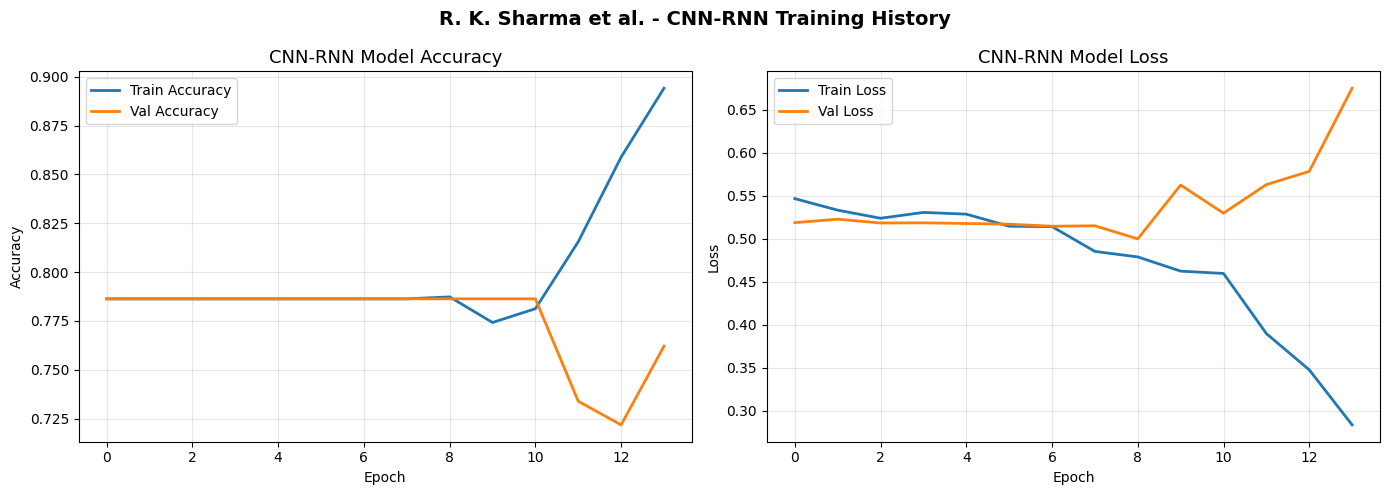

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0].set_title('CNN-RNN Model Accuracy', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[1].set_title('CNN-RNN Model Loss', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('R. K. Sharma et al. - CNN-RNN Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

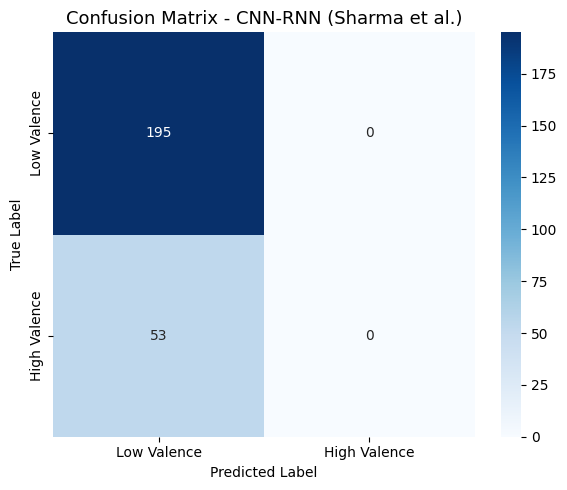

In [12]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Low Valence", "High Valence"],
            yticklabels=["Low Valence", "High Valence"])
plt.title("Confusion Matrix - CNN-RNN (Sharma et al.)", fontsize=13)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

---
# Part 2: Explainability and Interpretability (XAI)

The paper by R. K. Sharma et al. uses **SHAP (SHapley Additive exPlanations)** to provide interpretability for the CNN-RNN model. SHAP values quantify the contribution of each input feature to the model's prediction.

We analyze:
1. **EEG Channel Importance** - Which brain regions matter most for valence classification
2. **Temporal Segment Importance** - Which time periods are most informative
3. **Channel x Segment Heatmap** - Spatial-temporal interaction patterns
4. **Individual Sample Explanations** - Per-prediction feature attribution

## 10. SHAP Explainer Setup

The notebook first tries `shap.DeepExplainer`, which is closest to the paper's deep-learning XAI setup. If the installed SHAP/TensorFlow combination cannot backpropagate through the recurrent graph, it automatically falls back to `shap.GradientExplainer`, still producing SHAP values over the original input tensor `(segment, time sample, channel)`.


In [20]:
import shap

# Keep this small on Kaggle. Increase later if it works.
SHAP_BACKGROUND_SIZE = min(32, X_train.shape[0])
SHAP_EXPLAIN_SIZE = min(8, X_test.shape[0])
SHAP_NSAMPLES = 200

rng = np.random.default_rng(SHAP_RANDOM_STATE)

background_idx = rng.choice(X_train.shape[0], size=SHAP_BACKGROUND_SIZE, replace=False)
explain_idx = rng.choice(X_test.shape[0], size=SHAP_EXPLAIN_SIZE, replace=False)

shap_background = X_train[background_idx].astype(np.float32, copy=False)
shap_explain_data = X_test[explain_idx].astype(np.float32, copy=False)
shap_explain_labels = y_test[explain_idx].astype(np.float32, copy=False)
shap_explain_pred = model.predict(shap_explain_data, verbose=0).reshape(-1)

background_mean = shap_background.mean(axis=0).astype(np.float32)
n_groups = int(n_segments) * int(N_CHANNELS)

all_absent = np.zeros((1, n_groups), dtype=np.float32)
all_present = np.ones((1, n_groups), dtype=np.float32)

def make_segment_channel_masked_batch(mask_matrix, sample):
    mask_matrix = np.asarray(mask_matrix, dtype=np.float32)
    mask_matrix = np.clip(mask_matrix, 0.0, 1.0)

    masks = mask_matrix.reshape(mask_matrix.shape[0], int(n_segments), int(N_CHANNELS))
    batch = np.broadcast_to(
        background_mean,
        (mask_matrix.shape[0],) + background_mean.shape
    ).copy()

    batch += (sample[None] - background_mean[None]) * masks[:, :, None, :]
    return batch.astype(np.float32)

def explain_one_sample(sample):
    def grouped_predict(mask_matrix):
        masked_batch = make_segment_channel_masked_batch(mask_matrix, sample)
        return model.predict(masked_batch, batch_size=64, verbose=0).reshape(-1)

    explainer = shap.KernelExplainer(grouped_predict, all_absent)

    try:
        values = explainer.shap_values(
            all_present,
            nsamples=int(SHAP_NSAMPLES),
            silent=True,
        )
    except TypeError:
        values = explainer.shap_values(
            all_present,
            nsamples=int(SHAP_NSAMPLES),
        )

    if isinstance(values, list):
        values = values[0]

    values = np.asarray(values)

    if values.ndim == 3 and values.shape[-1] == 1:
        values = values[..., 0]

    return values.reshape(n_groups)

segment_channel_shap = []

for i, sample in enumerate(shap_explain_data):
    print(f"Explaining sample {i + 1}/{len(shap_explain_data)}...")
    segment_channel_shap.append(explain_one_sample(sample))

segment_channel_shap = np.stack(segment_channel_shap, axis=0)
segment_channel_shap = segment_channel_shap.reshape(
    len(shap_explain_data),
    int(n_segments),
    int(N_CHANNELS),
)

# Expand grouped segment-channel SHAP values back to:
# (samples, segments, time samples, channels)
shap_values = np.repeat(
    segment_channel_shap[:, :, None, :] / float(SEGMENT_LENGTH),
    int(SEGMENT_LENGTH),
    axis=2,
).astype(np.float32)

abs_shap_values = np.abs(shap_values)
global_feature_importance = abs_shap_values.mean(axis=0)

shap_explainer_name = "KernelExplainer grouped by segment x channel"

print(f"SHAP explainer:       {shap_explainer_name}")
print(f"Background examples:  {shap_background.shape}")
print(f"Explained examples:   {shap_explain_data.shape}")
print(f"SHAP values shape:    {shap_values.shape}")
print(f"Feature tensor shape: {global_feature_importance.shape}")


Explaining sample 1/8...
Explaining sample 2/8...
Explaining sample 3/8...
Explaining sample 4/8...
Explaining sample 5/8...
Explaining sample 6/8...
Explaining sample 7/8...
Explaining sample 8/8...
SHAP explainer:       KernelExplainer grouped by segment x channel
Background examples:  (32, 30, 256, 32)
Explained examples:   (8, 30, 256, 32)
SHAP values shape:    (8, 30, 256, 32)
Feature tensor shape: (30, 256, 32)


## 11. XAI Analysis 1: EEG Channel Importance

Top EEG channels by normalized mean |SHAP|:


,channel,mean_abs_shap
10,P3,0.141731
11,P7,0.108727
14,Oz,0.064118
6,C3,0.063987
1,AF3,0.059520
20,F8,0.048210
7,T7,0.042817
4,FC5,0.041280
18,Fz,0.040911
17,AF4,0.038594


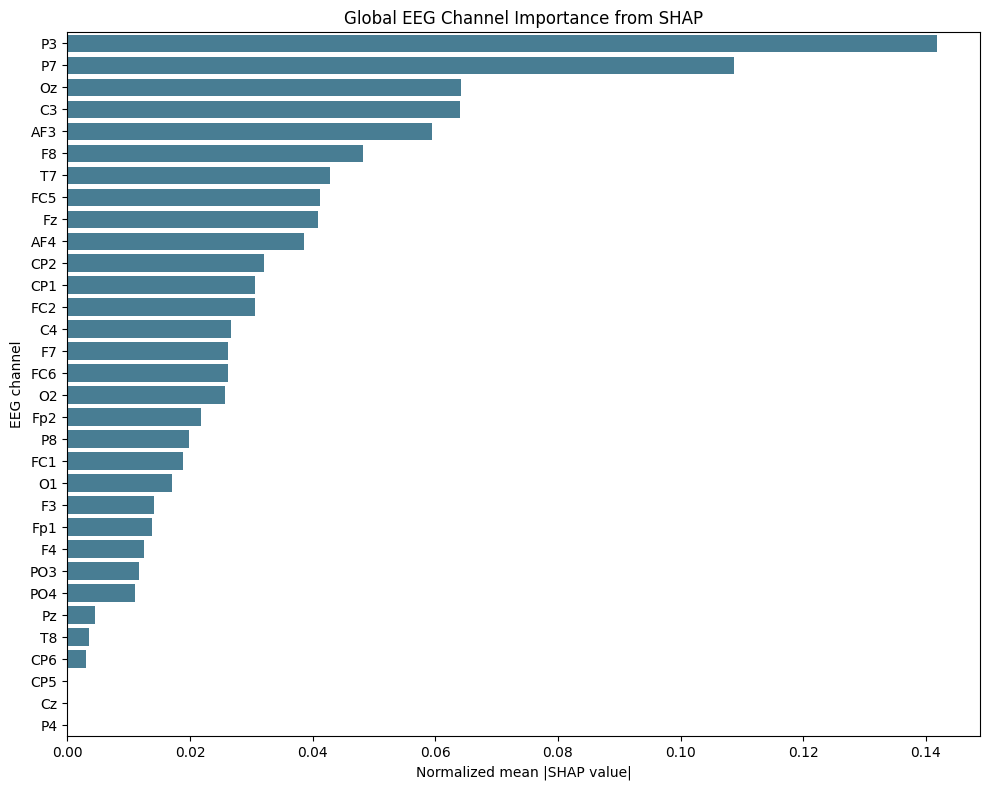

In [21]:
channel_importance = abs_shap_values.mean(axis=(0, 1, 2))
channel_importance = channel_importance / (channel_importance.sum() + 1e-12)

channel_importance_df = pd.DataFrame({
    "channel": EEG_CHANNEL_NAMES,
    "mean_abs_shap": channel_importance,
}).sort_values("mean_abs_shap", ascending=False)

print("Top EEG channels by normalized mean |SHAP|:")
display(channel_importance_df.head(12))

plt.figure(figsize=(10, 8))
sns.barplot(
    data=channel_importance_df,
    x="mean_abs_shap",
    y="channel",
    color="#3B82A0",
)
plt.title("Global EEG Channel Importance from SHAP")
plt.xlabel("Normalized mean |SHAP value|")
plt.ylabel("EEG channel")
plt.tight_layout()
plt.show()


## 12. XAI Analysis 2: Temporal Segment Importance

Top temporal segments by normalized mean |SHAP|:


,segment,time_window,mean_abs_shap
29,30,58-60s,0.245682
24,25,48-50s,0.086686
0,1,0-2s,0.072518
7,8,14-16s,0.062122
2,3,4-6s,0.057949
14,15,28-30s,0.045921
11,12,22-24s,0.042409
15,16,30-32s,0.039572
10,11,20-22s,0.038249
16,17,32-34s,0.037777


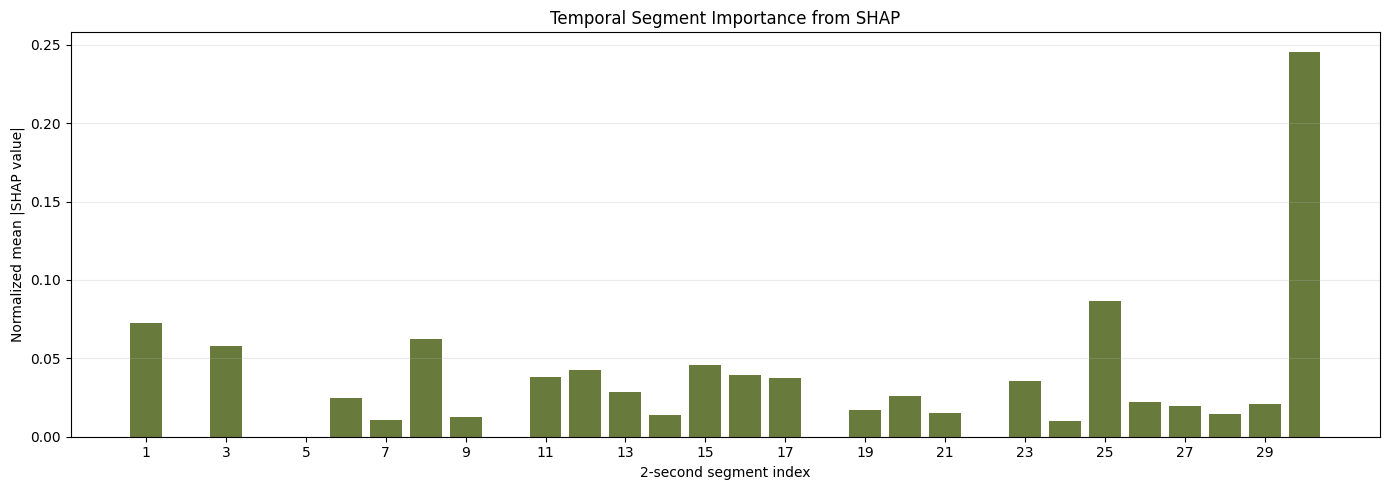

In [22]:
segment_importance = abs_shap_values.mean(axis=(0, 2, 3))
segment_importance = segment_importance / (segment_importance.sum() + 1e-12)

segment_starts = np.arange(n_segments) * SEGMENT_LENGTH_SEC
segment_labels = [
    f"{start}-{start + SEGMENT_LENGTH_SEC}s"
    for start in segment_starts
]

segment_importance_df = pd.DataFrame({
    "segment": np.arange(1, n_segments + 1),
    "time_window": segment_labels,
    "mean_abs_shap": segment_importance,
}).sort_values("mean_abs_shap", ascending=False)

print("Top temporal segments by normalized mean |SHAP|:")
display(segment_importance_df.head(10))

plt.figure(figsize=(14, 5))
plt.bar(np.arange(1, n_segments + 1), segment_importance, color="#687A3C")
plt.title("Temporal Segment Importance from SHAP")
plt.xlabel("2-second segment index")
plt.ylabel("Normalized mean |SHAP value|")
plt.xticks(np.arange(1, n_segments + 1, 2))
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


## 13. XAI Analysis 3: Channel x Segment Importance Heatmap

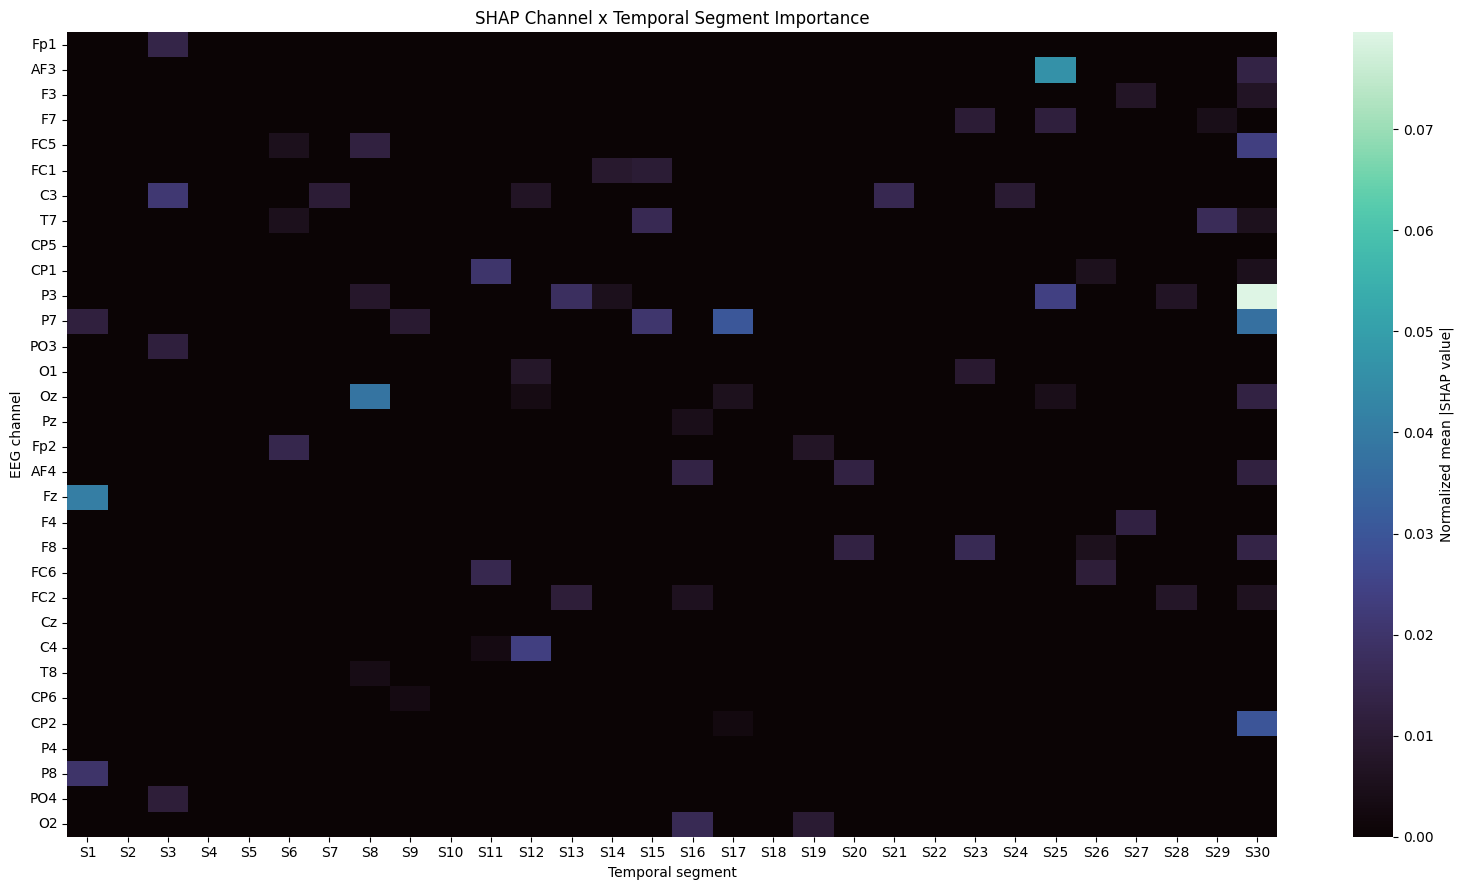

Top channel x segment pairs:


,segment,time_window,channel,mean_abs_shap
0,30,58-60s,P3,0.079585
1,25,48-50s,AF3,0.046278
2,1,0-2s,Fz,0.040911
3,8,14-16s,Oz,0.038034
4,30,58-60s,P7,0.036972
5,17,32-34s,P7,0.030163
6,30,58-60s,CP2,0.029830
7,25,48-50s,P3,0.024165
8,12,22-24s,C4,0.023903
9,30,58-60s,FC5,0.023870


In [23]:
segment_channel_importance = abs_shap_values.mean(axis=2).mean(axis=0)
segment_channel_importance = segment_channel_importance / (segment_channel_importance.sum() + 1e-12)

segment_channel_df = pd.DataFrame(
    segment_channel_importance.T,
    index=EEG_CHANNEL_NAMES,
    columns=[f"S{i}" for i in range(1, n_segments + 1)],
)

plt.figure(figsize=(16, 9))
sns.heatmap(
    segment_channel_df,
    cmap="mako",
    cbar_kws={"label": "Normalized mean |SHAP value|"},
)
plt.title("SHAP Channel x Temporal Segment Importance")
plt.xlabel("Temporal segment")
plt.ylabel("EEG channel")
plt.tight_layout()
plt.show()

flat_order = np.argsort(segment_channel_importance.reshape(-1))[::-1][:15]
top_pairs = []
for flat_idx in flat_order:
    seg_idx, channel_idx = np.unravel_index(flat_idx, segment_channel_importance.shape)
    top_pairs.append({
        "segment": int(seg_idx + 1),
        "time_window": segment_labels[seg_idx],
        "channel": EEG_CHANNEL_NAMES[channel_idx],
        "mean_abs_shap": float(segment_channel_importance[seg_idx, channel_idx]),
    })

top_segment_channel_pairs_df = pd.DataFrame(top_pairs)
print("Top channel x segment pairs:")
display(top_segment_channel_pairs_df)


## 14. XAI Analysis 4: Individual Sample Explanation

Explained test index: 90
True valence label:   Low (0)
Predicted probability of high valence: 0.2647
Predicted label:      Low (0)
Top channels for this prediction:


,channel,mean_signed_shap,mean_abs_shap
10,P3,-2.570800e-06,2.570800e-06
14,Oz,-1.750700e-06,1.750700e-06
5,FC1,-1.331511e-06,1.331511e-06
31,O2,-1.296752e-06,1.296752e-06
11,P7,-1.131446e-06,1.131446e-06
13,O1,-1.063166e-06,1.063166e-06
9,CP1,-6.257341e-07,6.257341e-07
27,CP2,-3.070174e-07,3.070174e-07
7,T7,0.000000e+00,0.000000e+00
6,C3,0.000000e+00,0.000000e+00


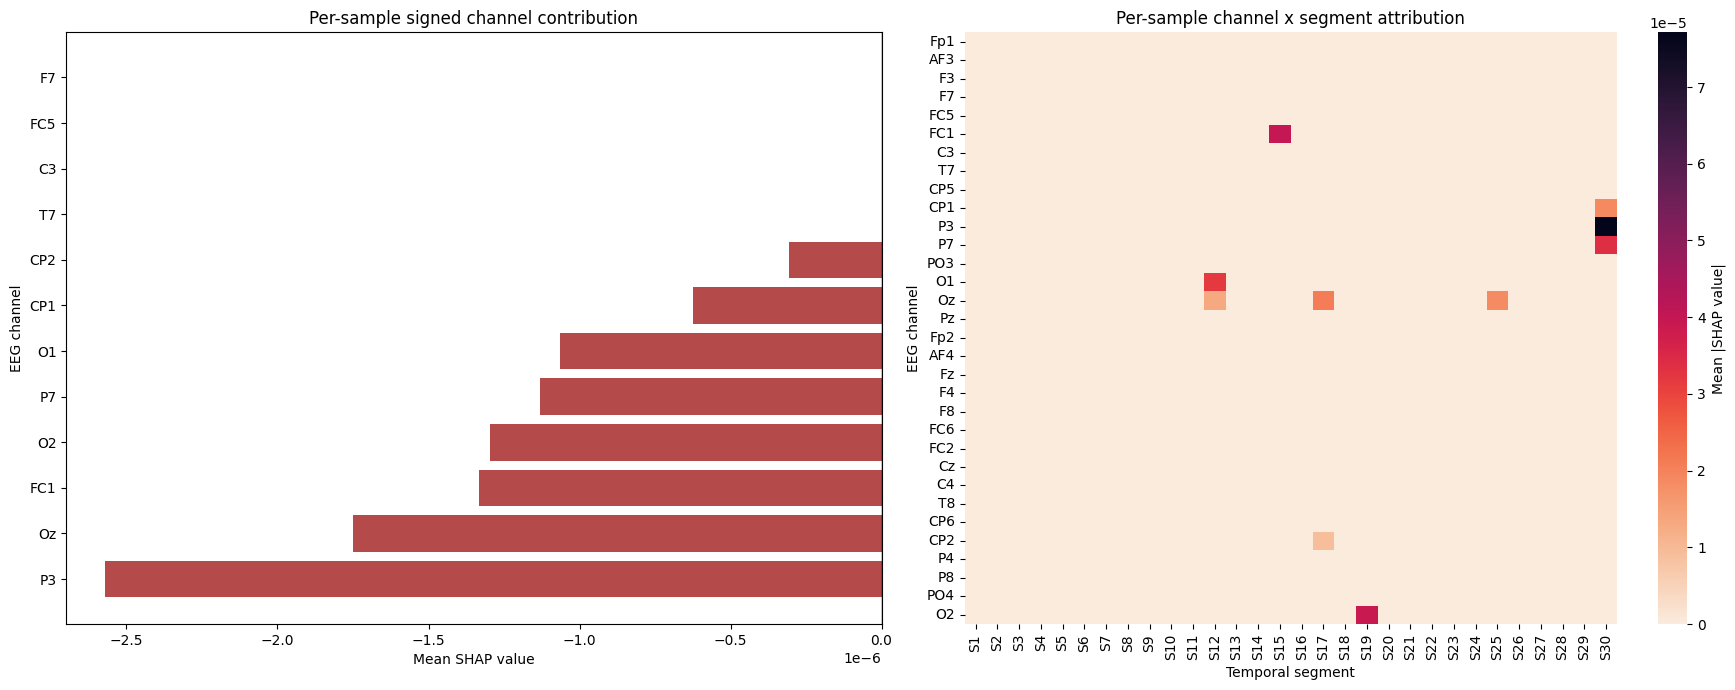

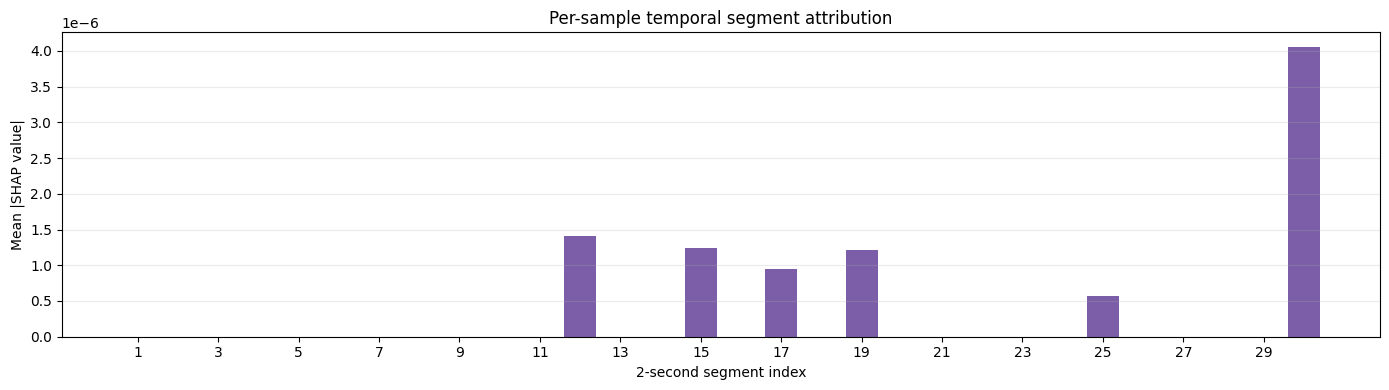

In [24]:
individual_position = 0
source_test_index = int(explain_idx[individual_position])
true_label = int(shap_explain_labels[individual_position])
pred_prob = float(shap_explain_pred[individual_position])
pred_label = int(pred_prob > 0.5)

sample_shap = shap_values[individual_position]
sample_abs_shap = np.abs(sample_shap)

sample_channel_signed = sample_shap.mean(axis=(0, 1))
sample_channel_abs = sample_abs_shap.mean(axis=(0, 1))
sample_segment_importance = sample_abs_shap.mean(axis=(1, 2))
sample_segment_channel = sample_abs_shap.mean(axis=1).T

sample_channel_df = pd.DataFrame({
    "channel": EEG_CHANNEL_NAMES,
    "mean_signed_shap": sample_channel_signed,
    "mean_abs_shap": sample_channel_abs,
}).sort_values("mean_abs_shap", ascending=False)

print(f"Explained test index: {source_test_index}")
print(f"True valence label:   {'High' if true_label else 'Low'} ({true_label})")
print(f"Predicted probability of high valence: {pred_prob:.4f}")
print(f"Predicted label:      {'High' if pred_label else 'Low'} ({pred_label})")
print("Top channels for this prediction:")
display(sample_channel_df.head(10))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plot_df = sample_channel_df.head(12).sort_values("mean_signed_shap")
bar_colors = ["#2F7D5C" if value >= 0 else "#B44A4A" for value in plot_df["mean_signed_shap"]]
axes[0].barh(plot_df["channel"], plot_df["mean_signed_shap"], color=bar_colors)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Per-sample signed channel contribution")
axes[0].set_xlabel("Mean SHAP value")
axes[0].set_ylabel("EEG channel")

sns.heatmap(
    pd.DataFrame(sample_segment_channel, index=EEG_CHANNEL_NAMES, columns=[f"S{i}" for i in range(1, n_segments + 1)]),
    cmap="rocket_r",
    cbar_kws={"label": "Mean |SHAP value|"},
    ax=axes[1],
)
axes[1].set_title("Per-sample channel x segment attribution")
axes[1].set_xlabel("Temporal segment")
axes[1].set_ylabel("EEG channel")

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.bar(np.arange(1, n_segments + 1), sample_segment_importance, color="#7B5EA7")
plt.title("Per-sample temporal segment attribution")
plt.xlabel("2-second segment index")
plt.ylabel("Mean |SHAP value|")
plt.xticks(np.arange(1, n_segments + 1, 2))
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()
